In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [8]:
# Load the car dataset
df = pd.read_csv('cars_data.csv')
print("📊 Dataset Preview:")
print(df.head())

# Independent variables (X)
X = df[['Weight', 'Volume']]

# Dependent variable (y)
y = df['CO2']

📊 Dataset Preview:
          Car       Model  Volume  Weight  CO2
0      Toyota        Aygo    1000     790   99
1  Mitsubishi  Space Star    1200    1160   95
2       Skoda      Citigo    1000     929   95
3        Fiat         500     900     865   90
4        Mini      Cooper    1500    1140  105


In [9]:
# Initialize and Train the Multiple Regression Model
model = LinearRegression()
model.fit(X, y)

print("✅ Multiple Regression model trained successfully.")

# Output the coefficients and intercept
print(f"\nCoefficients (Weight, Volume): {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")

✅ Multiple Regression model trained successfully.

Coefficients (Weight, Volume): [-0.00775097  0.00893283]
Intercept: 94.7344


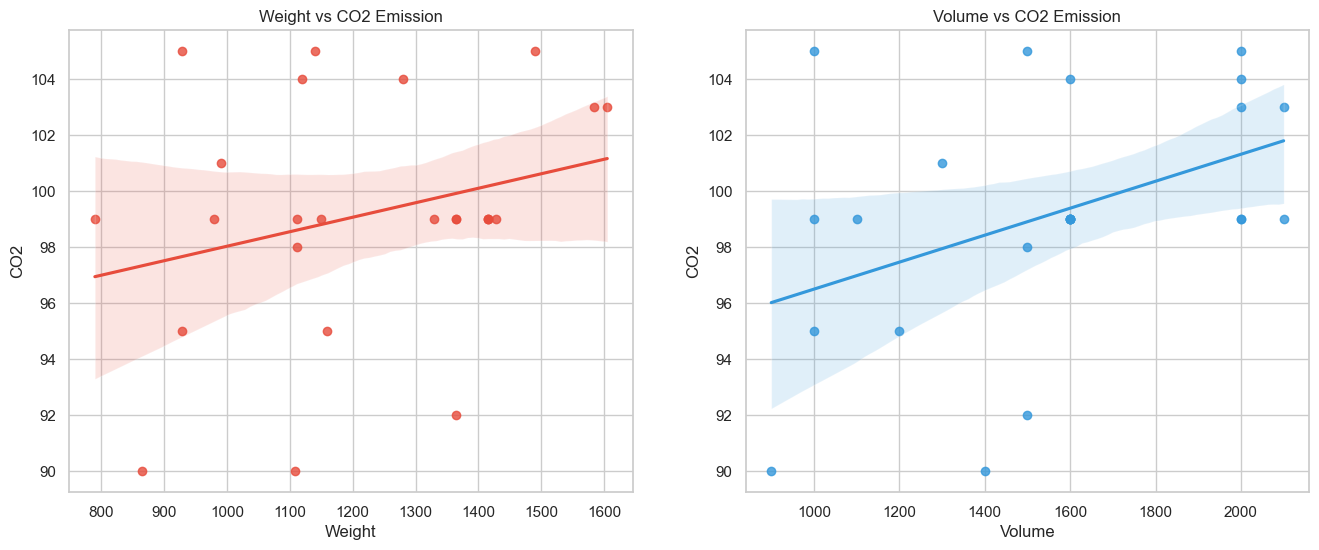

In [10]:
# Visualize relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(x='Weight', y='CO2', data=df, ax=ax1, color='#e74c3c')
ax1.set_title('Weight vs CO2 Emission')

sns.regplot(x='Volume', y='CO2', data=df, ax=ax2, color='#3498db')
ax2.set_title('Volume vs CO2 Emission')

plt.show()

In [11]:
# Custom Prediction Function with User Input
def predict_co2(weight, volume):
    prediction = model.predict([[weight, volume]])[0]
    print(f"\n🔮 Predicted CO2 Emission:")
    print(f"Weight: {weight}kg, Volume: {volume}ccm")
    print(f"Estimated CO2: {prediction:.2f}g/km")

# Get input from the user
try:
    u_weight = float(input("Enter car weight (kg): "))
    u_volume = float(input("Enter engine volume (ccm): "))
    predict_co2(u_weight, u_volume)
except ValueError:
    print("❌ Please enter numeric values.")


🔮 Predicted CO2 Emission:
Weight: 1000.0kg, Volume: 1800.0ccm
Estimated CO2: 103.06g/km


c:\Users\amand\Downloads\python\hmm\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [12]:
# Model Evaluation
y_pred = model.predict(X)
accuracy = r2_score(y, y_pred)
print(f"\n📈 Model R² Score: {accuracy:.4f}")
print("(Note: R² indicates how well the independent variables explain the variance of CO2)")


📈 Model R² Score: 0.2189
(Note: R² indicates how well the independent variables explain the variance of CO2)
